# **ANÁLISIS DE CHURN DE CLIENTES PARA UNA EMPRESA DE TELECOMUNICACIONES**

### Carga de funciones

In [1]:
#Importamos las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from collections import Counter


In [2]:
# cada vez que se guarde .py, Jupyter lo recargue automáticamente
%load_ext autoreload
%autoreload 2

Variables consideradas en el analisis

- **customerID**: Identificador único asignado a cada cliente en la base de datos.  
- **gender**: Género del cliente (por ejemplo, masculino o femenino).  
- **SeniorCitizen**: Indica si el cliente es una persona mayor (1 para sí, 0 para no).  
- **Partner**: Indica si el cliente tiene pareja (por ejemplo, "Yes" o "No").  
- **Dependents**: Indica si el cliente tiene personas dependientes.  
- **tenure**: Número de meses que el cliente ha estado con la empresa.  
- **PhoneService**: Indica si el cliente tiene contratado el servicio de teléfono.  
- **MultipleLines**: Indica si el cliente tiene más de una línea telefónica.  
- **InternetService**: Tipo de servicio de Internet contratado por el cliente.  
- **OnlineSecurity**: Indica si el cliente tiene un servicio de seguridad en línea (por ejemplo, "Yes" o "No").  
- **OnlineBackup**: Indica si el cliente tiene contratado un servicio de respaldo en línea.  
- **DeviceProtection**: Indica si el cliente tiene contratado un servicio para la protección de sus dispositivos.  
- **TechSupport**: Indica si el cliente tiene contratado un servicio de soporte técnico.  
- **StreamingTV**: Indica si el cliente tiene acceso a servicios de transmisión de televisión.  
- **StreamingMovies**: Indica si el cliente tiene acceso a servicios de transmisión de películas.  
- **Contract**: Tipo de contrato que tiene el cliente.  
- **PaperlessBilling**: Indica si el cliente utiliza facturación electrónica en lugar de facturas físicas.
- **PaymentMethod**: Método de pago utilizado por el cliente.  
- **MonthlyCharges**: Monto en dólares que el cliente paga mensualmente por los servicios.  
- **TotalCharges**: Monto total que el cliente ha pagado desde el inicio de su contrato.  
- **Churn**: Variable objetivo que indica si el cliente ha abandonado la empresa.  


### Carga de datos

In [3]:
# Desarrollar un modelo predictivo para detectar la fuga de clientes de una empresa de telecomunicaciones

# y (variable dependiente) : Churn
# Xs (variables independientes) : Todas menos el Churn, CustomerID

In [4]:
data = pd.read_csv("../data/external/Data_Customer_Churn.csv",sep = ';')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6798 entries, 0 to 6797
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        6798 non-null   object 
 1   gender            6798 non-null   object 
 2   SeniorCitizen     6798 non-null   int64  
 3   Partner           6798 non-null   object 
 4   Dependents        6798 non-null   object 
 5   tenure            6798 non-null   int64  
 6   PhoneService      6798 non-null   object 
 7   MultipleLines     6798 non-null   object 
 8   InternetService   6798 non-null   object 
 9   OnlineSecurity    6798 non-null   object 
 10  OnlineBackup      6798 non-null   object 
 11  DeviceProtection  6798 non-null   object 
 12  TechSupport       6798 non-null   object 
 13  StreamingTV       6798 non-null   object 
 14  StreamingMovies   6798 non-null   object 
 15  Contract          6798 non-null   object 
 16  PaperlessBilling  6798 non-null   object 


In [7]:
data.duplicated().sum() #data.drop_duplicated() esta funcion elimina las filas duplicadas de mi dataset

0

In [8]:
# Modelos de Clasificación

# 1. Limpieza de tu data
# 2. Analisis Descriptivo
# 3. Organizar tu data a formato numerico (variables cualitativas --> numericas (formato))
# 4. Particion de la data (train y test)
# 5. Balanceo de datos
# 6. Ejecucion de modelos
# 7. Optimizacion de hiperparametros

# **1. Análisis Descriptivo**

#### Análisis descriptivo de Churn

In [9]:
data["Churn"].value_counts(normalize = True) * 100 # Diferencia de 66.66666% y 33.333333%

Churn
No     73.580465
Yes    26.419535
Name: proportion, dtype: float64

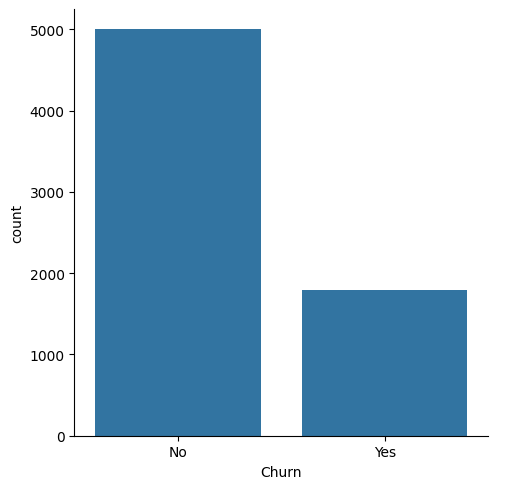

In [10]:
# visualizando la target
sns.catplot(x='Churn', data=data, kind="count")

#### Limpieza de datos

In [11]:
import sys
sys.path.append("../src")

In [12]:
from eda_evaluation import (
    obtener_variables,
    resumen_variables_categoricas,
    mostrar_nulos,
    imputar_valores,
    imputar_valores_extremos
)

In [13]:
# Obtener variables
numeric_vars, categorical_vars = obtener_variables(data)

In [14]:
numeric_vars

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [15]:
categorical_vars

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

#### Analizando variables numéricas

In [16]:
data.describe() # describe es una funcion para tener un reporte estadistico basico rapidamente

,SeniorCitizen,tenure,MonthlyCharges
count,6798.000000,6798.000000,6798.000000
mean,0.161665,32.369815,64.621139
std,0.368170,24.574880,30.136658
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.200000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>]], dtype=object)

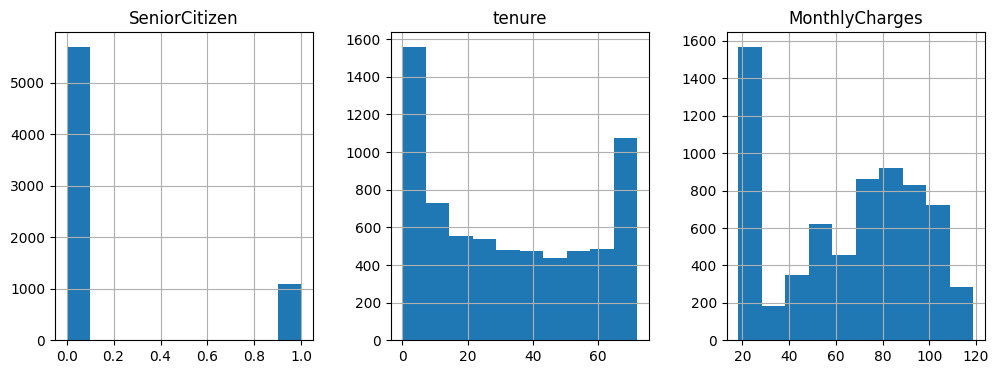

In [17]:
data.hist(figsize=(12, 4), layout=(1,3), bins=10)

In [18]:
# Actualizamos variables numericas

data["SeniorCitizen"] = data["SeniorCitizen"].astype("str")

numeric_vars.remove('SeniorCitizen')
categorical_vars.append('SeniorCitizen')
numeric_vars, categorical_vars

(['tenure', 'MonthlyCharges'],
 ['customerID',
  'gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'TotalCharges',
  'Churn',
  'SeniorCitizen'])

#### Analizando variables categóricas

In [19]:
# Resumen categórico
resumen_variables_categoricas(data)

Resumen de porcentajes para la variable 'customerID':

customerID
7590-VHVEG    0.01471
6728-WYQBC    0.01471
0378-TOVMS    0.01471
1100-DDVRV    0.01471
3428-XZMAZ    0.01471
               ...   
2506-CLAKW    0.01471
4529-CKBCL    0.01471
3126-WQMGH    0.01471
6204-IEUXJ    0.01471
8725-JEDFD    0.01471
Name: proportion, Length: 6798, dtype: float64

--------------------------------------------------

Resumen de porcentajes para la variable 'gender':

gender
Male      50.632539
Female    49.367461
Name: proportion, dtype: float64

--------------------------------------------------

Resumen de porcentajes para la variable 'SeniorCitizen':

SeniorCitizen
0    83.83348
1    16.16652
Name: proportion, dtype: float64

--------------------------------------------------

Resumen de porcentajes para la variable 'Partner':

Partner
No     51.691674
Yes    48.308326
Name: proportion, dtype: float64

--------------------------------------------------

Resumen de porcentajes para la variable 'D

In [20]:
# Actualizamos variables categoricas

data["TotalCharges"] = data["TotalCharges"].replace(" ",np.nan)
data["TotalCharges"] = data["TotalCharges"].astype("float")

categorical_vars.remove('TotalCharges')
numeric_vars.append('TotalCharges')

In [21]:
categorical_vars

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [22]:
numeric_vars

['tenure', 'MonthlyCharges', 'TotalCharges']

#### Mostrando presencia de valores perdidos

In [23]:
# Nulos antes de imputar
mostrar_nulos(data)

customerID: 0.00%
gender: 0.00%
SeniorCitizen: 0.00%
Partner: 0.00%
Dependents: 0.00%
tenure: 0.00%
PhoneService: 0.00%
MultipleLines: 0.00%
InternetService: 0.00%
OnlineSecurity: 0.00%
OnlineBackup: 0.00%
DeviceProtection: 0.00%
TechSupport: 0.00%
StreamingTV: 0.00%
StreamingMovies: 0.00%
Contract: 0.00%
PaperlessBilling: 0.00%
PaymentMethod: 0.00%
MonthlyCharges: 0.00%
TotalCharges: 0.16%
Churn: 0.00%


array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

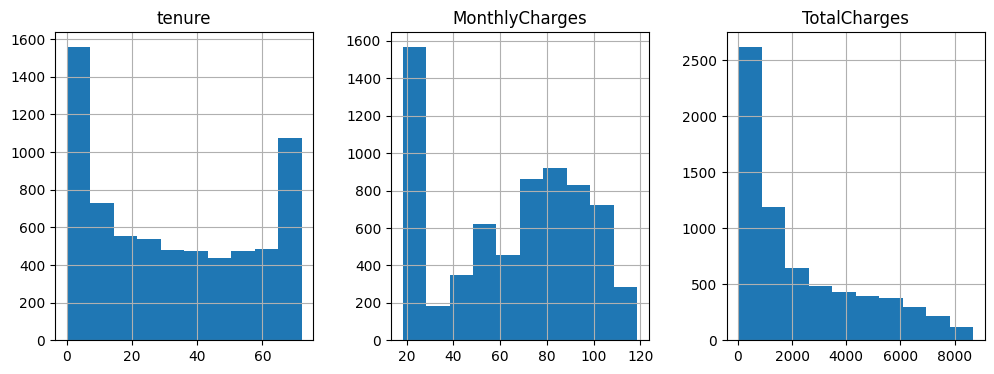

In [24]:
data.hist(figsize=(12, 4), layout=(1,3), bins=10)

In [25]:
# Imputación
data = imputar_valores(
    data,
    "TotalCharges",
    metodo="mediana"
)

c:\cesar_quezada\ProyectosIA\03. Proyectos_SOLUCIONES_DIG\Telecom-Customer-Churn-Prediction\notebooks\../src\eda_evaluation.py:220: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[variable].fillna(


In [26]:
# Nulos después de imputar
mostrar_nulos(data)

customerID: 0.00%
gender: 0.00%
SeniorCitizen: 0.00%
Partner: 0.00%
Dependents: 0.00%
tenure: 0.00%
PhoneService: 0.00%
MultipleLines: 0.00%
InternetService: 0.00%
OnlineSecurity: 0.00%
OnlineBackup: 0.00%
DeviceProtection: 0.00%
TechSupport: 0.00%
StreamingTV: 0.00%
StreamingMovies: 0.00%
Contract: 0.00%
PaperlessBilling: 0.00%
PaymentMethod: 0.00%
MonthlyCharges: 0.00%
TotalCharges: 0.00%
Churn: 0.00%


## Preprocesamiento de datos

In [27]:
# Retirando la variable target de la lista de vaiables categoricas
categorical_vars.remove('Churn')
categorical_vars.remove('customerID')

In [28]:
import sys
sys.path.append("../src")

from preprocessing import separar_variables


In [29]:
# Guardar todas las variables categoricas en un solo lugar
num_cols, cat_cols = separar_variables(
    data,
    numeric_vars,
    categorical_vars
)

In [30]:
# Generar variables para las dos columnas que omiti de mi mapeo de variables cualitativas y cuantitativas

id_customer = data["customerID"]

from preprocessing import obtener_target
label = obtener_target(data)

In [31]:
# Transformacion de variables categoricas a numericas

# Label encoding (Target Encoding) : Cambiar en la misma columna el valor categorico a numerico

# Nivel_Instruccion
# -----------------
# Superior  --> 3
# Secundaria -> 2
# Tecnico. ---> 1
# Superior ---> 3
# Tecnico. ---> 1


# One hot encoding : Genera nuevas columnas dicotomicas a partir de las categorias de las variables categoricas

In [32]:
label

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
6793     No
6794     No
6795     No
6796    Yes
6797     No
Name: Churn, Length: 6798, dtype: object

In [33]:
# La variable target categorica solo puede ser transformada con el target encoding

from preprocessing import target_encoding_binario

label = target_encoding_binario(label)

In [34]:
label 

0       0
1       0
2       1
3       0
4       1
       ..
6793    0
6794    0
6795    0
6796    1
6797    0
Name: Churn, Length: 6798, dtype: int64

In [35]:
# Tenure, Monthly Charges y Total Charges son variables cuantitativas independientes
# Multicolinealidad : Si tienes pares de variables cuantitativas independientes correlacionadas solo debes utilizar a una
# Se elimina por un tema de eficiencia computacional
# Si las variables estan correlacionadas significa que el aporte va a ser el mismo
# Los modelos tengan una cantidad optima de variables independientes

<Axes: >

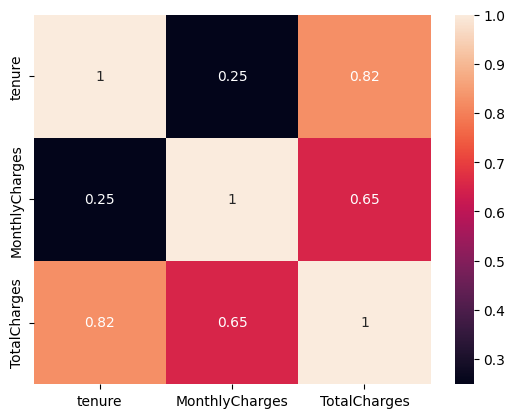

In [36]:
# La matriz de correlacion considera el coeficiente de correlacion de Pearson
# El coeficiente de correlacion de pearson se analiza SOLO para verificar la RELACION LINEAL entre VARIABLES CUANTITATIVAS
# Si la variable tiene formato numerico pero ORIGINALMENTE es una variable CATEGORICA no aplica para la matriz de correlacion

# sns.heatmap(data.select_dtypes(include=['number']).corr(),annot=True)
sns.heatmap(data[numeric_vars].corr(),annot=True)

¿Cómo saber cual variable eliminar de mi modelo?

In [37]:
# Niveles de correlaciones simples (Mutual Information - MI)
# --------------------------------

from sklearn.feature_selection import mutual_info_classif

# Si la variable target es categórica, puedes usar mutual information
mi = mutual_info_classif(data[['tenure','TotalCharges']], data['Churn'], discrete_features=False)

print(f'Mutual Information de tenure con target: {mi[0]}')
print(f'Mutual Information de TotalCharges con target: {mi[1]}')

Mutual Information de tenure con target: 0.06560964243207379
Mutual Information de TotalCharges con target: 0.043901968186430995


In [38]:
# Analizando importancia de variables en un modelo simple
# -----------------------------------
from sklearn.tree import DecisionTreeClassifier

# Separar las variables de entrada y la target
X = data[['tenure','TotalCharges']]
y = data['Churn']

# Entrenar un árbol de decisión
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X, y)

# Obtener la importancia de las variables
importances = tree.feature_importances_

print(f'Importancia de tenure: {importances[0]}')
print(f'Importancia de TotalCharges: {importances[1]}')

Importancia de tenure: 0.29523662113724947
Importancia de TotalCharges: 0.7047633788627505


In [39]:
# retirando la variable que menos aporta
numeric_vars.remove('tenure')
numeric_vars

del num_cols['tenure']

Realizamos el proceso de one hot encoding con nuestras variables categóricas:

In [40]:
cat_cols.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,0
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,0
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0


In [41]:
from preprocessing import aplicar_one_hot_encoding

cat_cols = aplicar_one_hot_encoding(cat_cols)

In [42]:
cat_cols.head()

,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_0,SeniorCitizen_1
0,True,False,False,True,True,False,True,False,False,True,...,False,False,False,True,False,False,True,False,True,False
1,False,True,True,False,True,False,False,True,True,False,...,True,False,True,False,False,False,False,True,True,False
2,False,True,True,False,True,False,False,True,True,False,...,False,False,False,True,False,False,False,True,True,False
3,False,True,True,False,True,False,True,False,False,True,...,True,False,True,False,True,False,False,False,True,False
4,True,False,True,False,True,False,False,True,True,False,...,False,False,False,True,False,False,True,False,True,False


In [43]:
cat_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6798 entries, 0 to 6797
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   gender_Female                            6798 non-null   bool 
 1   gender_Male                              6798 non-null   bool 
 2   Partner_No                               6798 non-null   bool 
 3   Partner_Yes                              6798 non-null   bool 
 4   Dependents_No                            6798 non-null   bool 
 5   Dependents_Yes                           6798 non-null   bool 
 6   PhoneService_No                          6798 non-null   bool 
 7   PhoneService_Yes                         6798 non-null   bool 
 8   MultipleLines_No                         6798 non-null   bool 
 9   MultipleLines_No phone service           6798 non-null   bool 
 10  MultipleLines_Yes                        6798 non-null   bool 
 11  Inte

Creamos una nueva data donde concatenamos la data original con la data que contiene las nuevas variables de one-hot-encoding:

In [44]:
from preprocessing import construir_dataset_final

df_complete = construir_dataset_final(
    num_cols,
    cat_cols,
    label
)

In [45]:
df_complete.head()

,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,...,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_0,SeniorCitizen_1,Churn
0,29.85,29.85,True,False,False,True,True,False,True,False,...,False,False,True,False,False,True,False,True,False,0
1,56.95,1889.50,False,True,True,False,True,False,False,True,...,False,True,False,False,False,False,True,True,False,0
2,53.85,108.15,False,True,True,False,True,False,False,True,...,False,False,True,False,False,False,True,True,False,1
3,42.30,1840.75,False,True,True,False,True,False,True,False,...,False,True,False,True,False,False,False,True,False,0
4,70.70,151.65,True,False,True,False,True,False,False,True,...,False,False,True,False,False,True,False,True,False,1


In [46]:
df_complete.shape

(6798, 46)

## Particionado de datos

In [47]:
# !pip install imbalanced-learn

In [48]:
from collections import Counter

from balancing import (
    train_test_split_data,
    oversampling,
    undersampling,
    aplicar_smote
)

In [49]:
X_train_res, X_test, y_train_res, y_test = (
    train_test_split_data(
        df_complete,
        target="Churn",
        test_size=0.3,
        random_state=10
    )
)

In [50]:
X_train_res.shape, y_train_res.shape

((4758, 45), (4758,))

In [51]:
X_test.shape, y_test.shape

((2040, 45), (2040,))

## Balanceo de las clases de variable a predecir (Churn)

In [52]:
# Sobremuestreo : Duplicar observaciones de la clase minoritaria para igualar la cantidad de muestras
# Submuestreo : Eliminar observaciones de la clase mayoritaria para equilibrar proporciones
# Generación sintética de muestras (SMOTE) : crear observaciones sinteticas de la clase minoritaria
# Pesos de clases : Asignan pesos distintos a las clases durante el entrenamiento para compensar el desequilibrio (class weighting)
# Ensambles de modelos : Construir ensambles que se centren mas en la clase minoritaria, como EasyEnsemble o BalanceCascade
# Tecnicas hibridas : combinar enfoques, como aplicar sobremuestreo a la clase minoritaria y submuestreo a la clase mayoritaria

Como vimos en los análisis descriptivos el % de clientes churn representaba alrededor de un 26% de la data total, lo que nos indica que existe una diferencia de alrededor del 50% con la cantidad de clientes que seguían siendo parte de la empresa, en términos de predicción es recomendable trata de crear muestras de datos que equiparen los % de distribución de ambas clases.

Hay varios métodos de muestreo que han sido diseñados para tratar datos desbalanceados, los cuales pueden ser agrupados en cuatro categorías: submuestreo, sobremuestreo, generación de datos sintéticos y aprendizaje sensible al costo. Todos estos métodos modifican la proporción de las clases y el tamaño del dataset original.

Los métodos de submuestreo eliminan observaciones de la clase mayoritaria con el fin de igualar los tamaños de las clases.

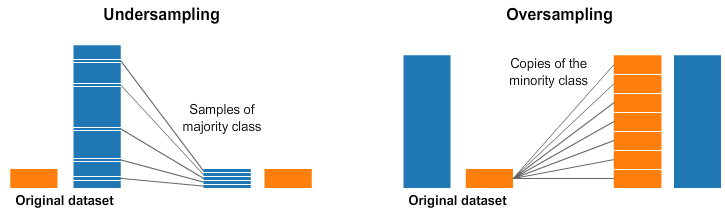

#### Oversampling

In [53]:
upsample_data_complete = oversampling(
    X_train_res,
    y_train_res,
    n_samples=3506
)

In [54]:
upsample_data_complete["Churn"].value_counts()

Churn
0    3506
1    3506
Name: count, dtype: int64

In [55]:
upsample_data_complete.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7012 entries, 1288 to 4594
Data columns (total 46 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   MonthlyCharges                           7012 non-null   float64
 1   TotalCharges                             7012 non-null   float64
 2   gender_Female                            7012 non-null   bool   
 3   gender_Male                              7012 non-null   bool   
 4   Partner_No                               7012 non-null   bool   
 5   Partner_Yes                              7012 non-null   bool   
 6   Dependents_No                            7012 non-null   bool   
 7   Dependents_Yes                           7012 non-null   bool   
 8   PhoneService_No                          7012 non-null   bool   
 9   PhoneService_Yes                         7012 non-null   bool   
 10  MultipleLines_No                         7012 non-

#### Undersampling

In [56]:
undersample_data_complete = undersampling(
    X_train_res,
    y_train_res,
    n_samples=1252
)

In [57]:
undersample_data_complete["Churn"].value_counts()

Churn
0    1252
1    1252
Name: count, dtype: int64

#### SMOTE

In [58]:
X_train_smote, y_train_smote = aplicar_smote(
    X_train_res,
    y_train_res,
    sampling_strategy=0.6
)

In [59]:
Counter(y_train_smote)

Counter({0: 3506, 1: 2103})

## Evaluación de Algoritmos

In [61]:
# Seleccionamos el tipo de remuestreo que mejor nos beneficie
# ---------------
#X_train = X_train_res
#y_train = y_train_res

X_train = X_train_smote
y_train = y_train_smote


X_train.shape, y_train.shape

((5609, 45), (5609,))

Importamos las librerías de 5 tipos de algoritmos de clasificación:

1. Árboles de decisión
2. Regresión logística
3. XgBoost
4. Random forest

In [62]:
# CURVA ROC: Grafico que muestra el rendimiento de un modelo de clasificacion en todos los umbrales donde realiza la clasificacion

# A partir del recall y precision



# AUC (Area bajo la curva) : Indicador

# PARTICION DE LA DATA (TRAIN Y TEST)

# AUC, ACCURACY, F1-SCORE (SEAN SIMILARES TANTO PARA LA DATA DE TRAIN COMO PARA LA DATA DE TEST)

# 1. METRICAS SIMILARES EN TRAIN Y TEST (BUEN AJUSTE DEL MODELO Y RESULTADOS CONSISTENTES)
# 2. METRICAS ALTAS EN TRAIN Y BAJAS EN TEST (SOBREAJUSTE - OVERFITTING)
# 3. METRICAS BAJAS EN TRAIN Y BAJAS EN TEST (SUBAJUSTE)


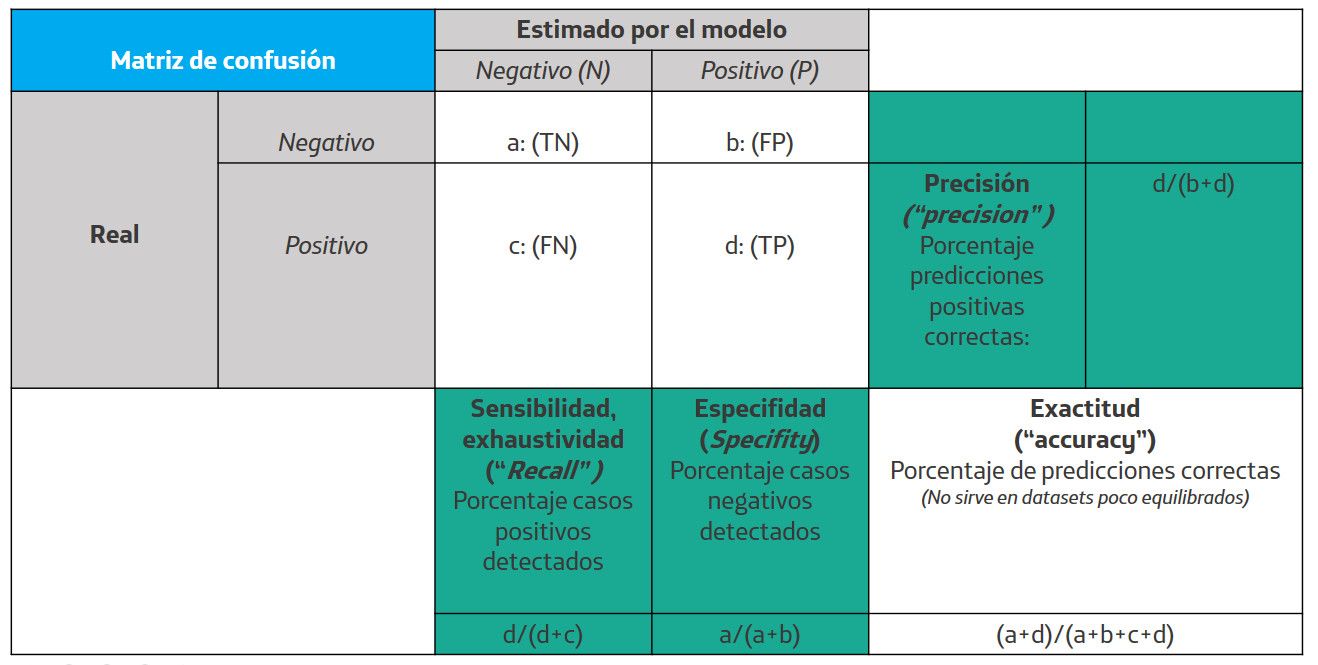

In [60]:
from evaluation import (
    obtener_matriz_confusion,
    confusion_matrix_graph,
    model_classification_report,
    roc_curve_graph,
    calcular_auc
)

In [63]:
from train_model import (
    train_model,
    generate_predictions,
    save_model
)

#### Decision Tree

In [64]:
from sklearn.tree import DecisionTreeClassifier

In [65]:
DT = DecisionTreeClassifier(
    criterion="gini",
    random_state=100,
    max_depth=5,
    min_samples_leaf=4
)

In [66]:
DT = train_model(
    DT,
    X_train,
    y_train
)

In [ ]:
y_train_predict_dt, y_test_predict_dt, y_train_predict_proba_dt, y_test_predict_proba_dt = generate_predictions( DT, X_train, X_test)

In [68]:
y_train_predict_dt

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [69]:
y_train_predict_proba_dt

array([[0.45054945, 0.54945055],
       [0.98694517, 0.01305483],
       [0.96226415, 0.03773585],
       ...,
       [0.18282112, 0.81717888],
       [0.18282112, 0.81717888],
       [0.18282112, 0.81717888]])

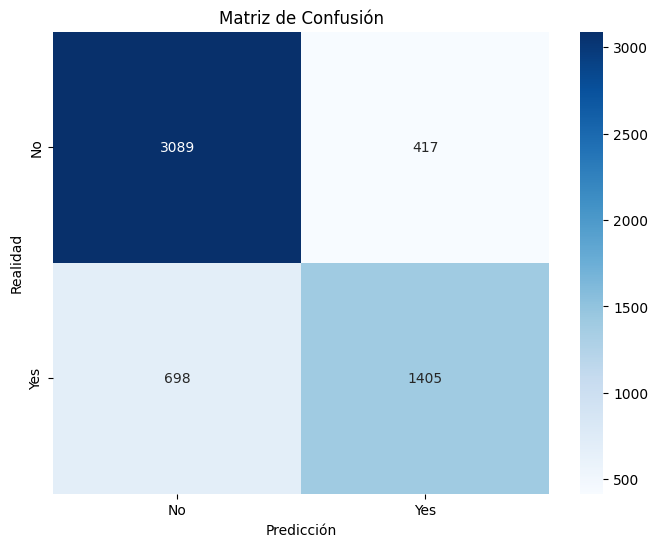

In [71]:
cm_dt = obtener_matriz_confusion(
    y_train,
    y_train_predict_dt
)
confusion_matrix_graph(cm_dt)

In [72]:
model_classification_report(y_train, y_train_predict_dt)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      3506
           1       0.77      0.67      0.72      2103

    accuracy                           0.80      5609
   macro avg       0.79      0.77      0.78      5609
weighted avg       0.80      0.80      0.80      5609



In [73]:
model_classification_report(y_test, y_test_predict_dt)

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1496
           1       0.60      0.53      0.57       544

    accuracy                           0.78      2040
   macro avg       0.72      0.70      0.71      2040
weighted avg       0.77      0.78      0.78      2040



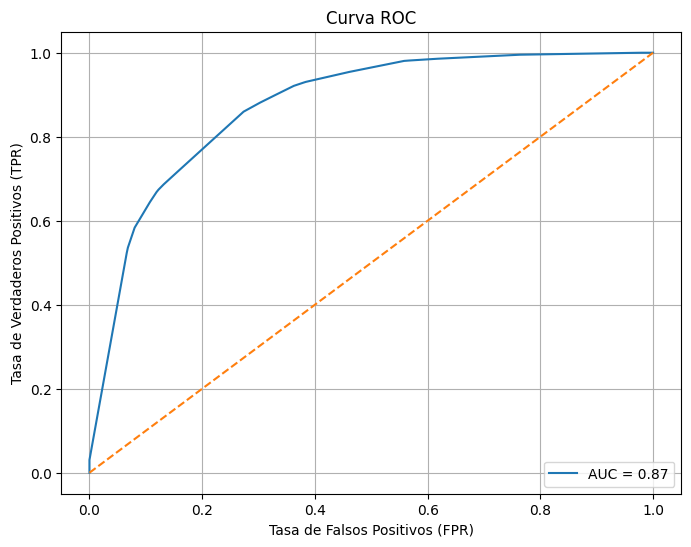

In [74]:
roc_curve_graph(
    y_train,
    y_train_predict_proba_dt
)

#### Logistic regresion

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
LG = LogisticRegression(
    max_iter=1000
)

In [77]:
LG = train_model(
    LG,
    X_train,
    y_train
)

c:\Users\CESAR QUEZADA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [78]:
y_train_predict_lgr, y_test_predict_lgr, y_train_predict_proba_lgr, y_test_predict_proba_lgr = generate_predictions(LG, X_train, X_test)

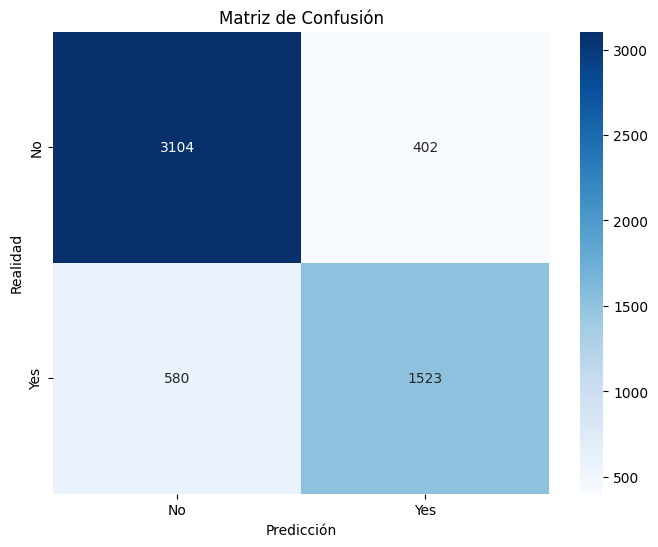

In [79]:
cm_lgr = obtener_matriz_confusion(
    y_train,
    y_train_predict_lgr
)

confusion_matrix_graph(cm_lgr)

In [81]:
model_classification_report(y_train,y_train_predict_lgr)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      3506
           1       0.79      0.72      0.76      2103

    accuracy                           0.82      5609
   macro avg       0.82      0.80      0.81      5609
weighted avg       0.82      0.82      0.82      5609



In [82]:
model_classification_report(y_test, y_test_predict_lgr)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1496
           1       0.65      0.57      0.61       544

    accuracy                           0.80      2040
   macro avg       0.75      0.73      0.74      2040
weighted avg       0.80      0.80      0.80      2040



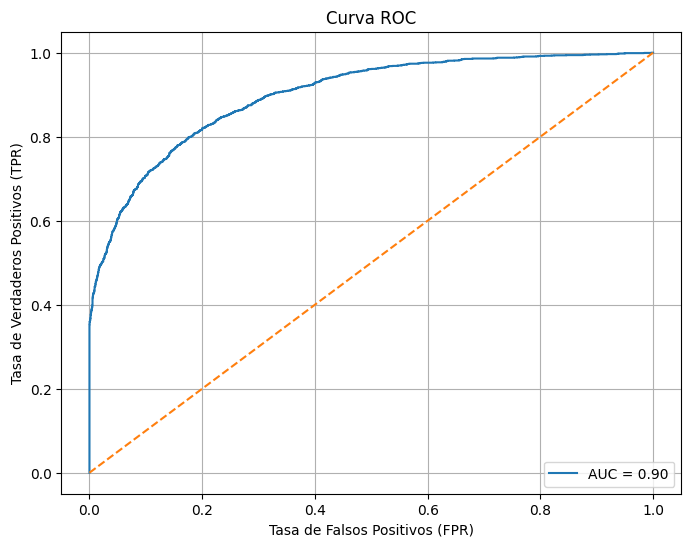

In [83]:
roc_curve_graph(
    y_train,
    y_train_predict_proba_lgr
)

#### Random Forest

In [84]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
RF = RandomForestClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=4,
    n_estimators=100,
    random_state=123
)

In [86]:
RF = train_model(
    RF,
    X_train,
    y_train
)

In [87]:
y_train_predict_rf, y_test_predict_rf, y_train_predict_proba_rf, y_test_predict_proba_rf = generate_predictions( RF, X_train, X_test)

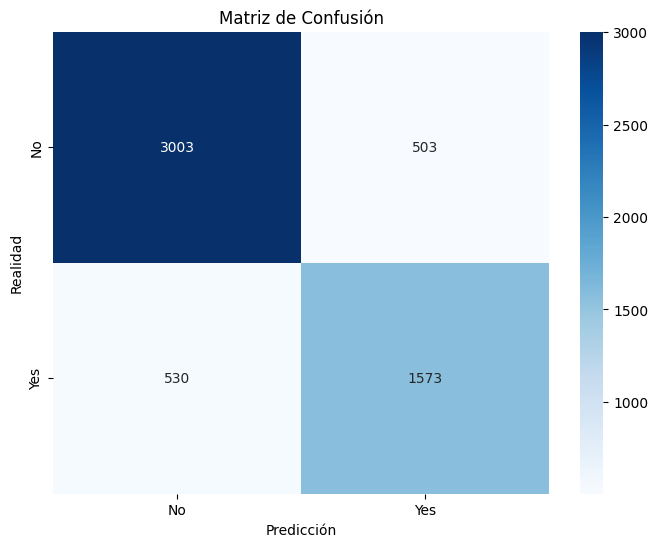

In [88]:
cm_rf = obtener_matriz_confusion(
    y_train,
    y_train_predict_rf
)

confusion_matrix_graph(cm_rf)

In [89]:
model_classification_report(y_test, y_test_predict_rf)

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1496
           1       0.60      0.59      0.59       544

    accuracy                           0.79      2040
   macro avg       0.73      0.72      0.72      2040
weighted avg       0.78      0.79      0.79      2040



In [90]:
model_classification_report(y_test,y_test_predict_rf)

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1496
           1       0.60      0.59      0.59       544

    accuracy                           0.79      2040
   macro avg       0.73      0.72      0.72      2040
weighted avg       0.78      0.79      0.79      2040



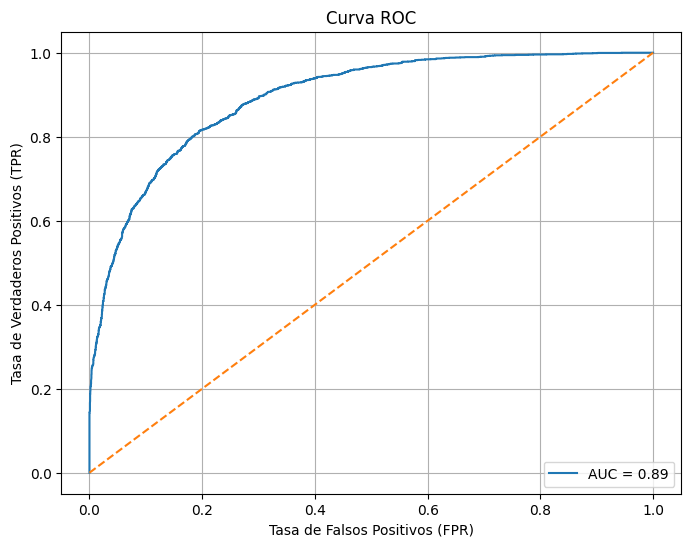

In [91]:
roc_curve_graph(
    y_train,
    y_train_predict_proba_rf
)

#### XGBoost

In [95]:
# !pip install xgboost

In [96]:
import xgboost as xgb

In [97]:
XGB = xgb.XGBClassifier(
    objective="binary:logistic",
    random_state=42
)

In [98]:
XGB = train_model(
    XGB,
    X_train,
    y_train
)

In [99]:
y_train_predict_xgb, y_test_predict_xgb, y_train_predict_proba_xgb, y_test_predict_proba_xgb = generate_predictions(XGB, X_train, X_test)

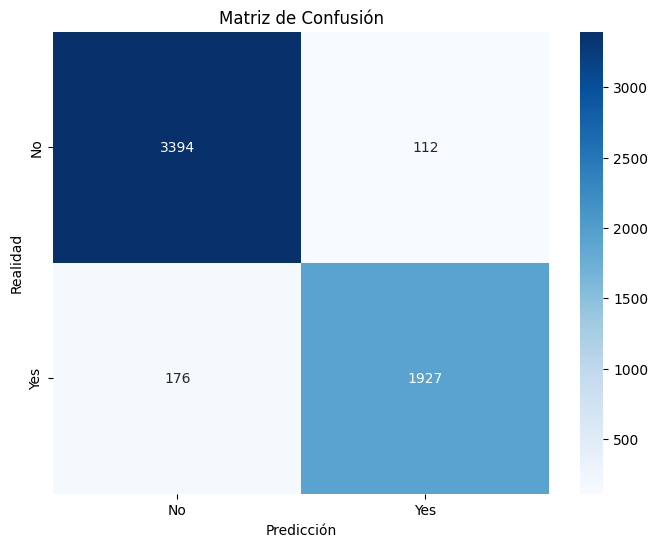

In [100]:
cm_xgb = obtener_matriz_confusion(
    y_train,
    y_train_predict_xgb
)

confusion_matrix_graph(cm_xgb)

In [101]:
model_classification_report(y_train, y_train_predict_xgb)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3506
           1       0.95      0.92      0.93      2103

    accuracy                           0.95      5609
   macro avg       0.95      0.94      0.94      5609
weighted avg       0.95      0.95      0.95      5609



In [102]:
model_classification_report(y_test, y_test_predict_xgb)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1496
           1       0.63      0.54      0.58       544

    accuracy                           0.79      2040
   macro avg       0.73      0.71      0.72      2040
weighted avg       0.78      0.79      0.79      2040



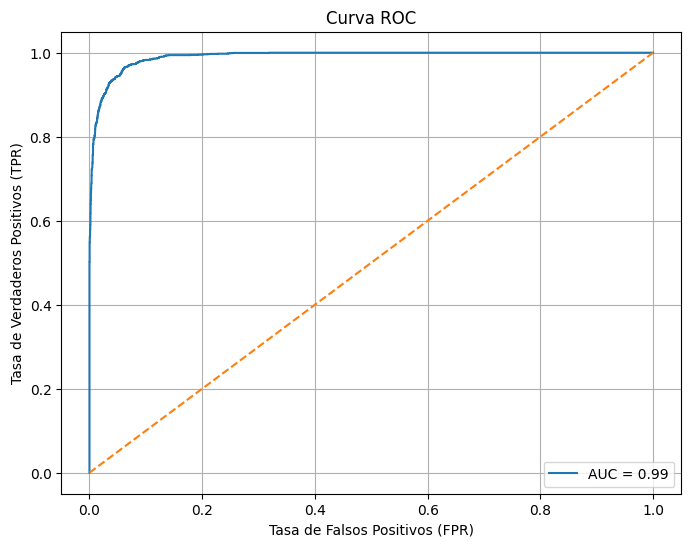

In [103]:
roc_curve_graph(
    y_train,
    y_train_predict_proba_xgb
)

Aparentemente la Regresión Logística y XgBoost me está entregando mejores resultados de predicción del Churn, esto sin realizar ningún ajuste a los modelos.

## Guardando los modelos para un uso posterior

In [108]:
save_model(DT, "../models/decision_tree.pkl")

Modelo guardado en: ../models/decision_tree.pkl


In [105]:
save_model(LG, "../models/logistic_regression.pkl")

Modelo guardado en: ../models/logistic_regression.pkl


In [106]:
save_model(RF,"../models/random_forest.pkl")

Modelo guardado en: ../models/random_forest.pkl


In [107]:
save_model(XGB, "../models/xgboost.pkl")

Modelo guardado en: ../models/xgboost.pkl
